# **ЛАБОРАТОРНАЯ РАБОТА 3. БИБЛИОТЕКИ PYTHON ДЛЯ DATA-SCIENCE: МИНИ-ПАЙПЛАЙН**

## **1. Подключение библиотек**

In [1]:
import json
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 20)
pd.set_option('display.max_colwidth', None)

## **2. Таблица сопоставления библиотек и областей применения**

In [3]:
library_map = [
    {'Библиотека': 'NumPy', 'Назначение': 'числовые вычисления, массивы', 'Ключевые объекты/функции': 'ndarray, mean, std, where', 'Пример': 'np.array(x).mean()'},
    {'Библиотека': 'Pandas', 'Назначение': 'табличные данные', 'Ключевые объекты/функции': 'DataFrame, read_csv, groupby, merge', 'Пример': "df.groupby('day')['temp'].mean()"},
    {'Библиотека': 'Matplotlib', 'Назначение': 'базовая визуализация', 'Ключевые объекты/функции': 'plt.plot, plt.scatter, plt.xlabel', 'Пример': "plt.plot(df['time'], df['temp'])"},
    {'Библиотека': 'Seaborn', 'Назначение': 'статистическая визуализация', 'Ключевые объекты/функции': 'sns.lineplot, sns.histplot, sns.boxplot', 'Пример': "sns.histplot(df['temp'])"},
    {'Библиотека': 'Requests', 'Назначение': 'HTTP‑запросы к API', 'Ключевые объекты/функции': 'requests.get, status_code, json()', 'Пример': "requests.get(url, params=params)"}
]
pd.DataFrame(library_map)

,Библиотека,Назначение,Ключевые объекты/функции,Пример
0,NumPy,"числовые вычисления, массивы","ndarray, mean, std, where",np.array(x).mean()
1,Pandas,табличные данные,"DataFrame, read_csv, groupby, merge",df.groupby('day')['temp'].mean()
2,Matplotlib,базовая визуализация,"plt.plot, plt.scatter, plt.xlabel","plt.plot(df['time'], df['temp'])"
3,Seaborn,статистическая визуализация,"sns.lineplot, sns.histplot, sns.boxplot",sns.histplot(df['temp'])
4,Requests,HTTP‑запросы к API,"requests.get, status_code, json()","requests.get(url, params=params)"


## **3. Получение данных из API**

In [4]:
url = 'https://api.open-meteo.com/v1/forecast'
params = {
    'latitude': 42.3417,
    'longitude': 69.5901,
    'hourly': 'temperature_2m',
    'forecast_days': 2,
    'timezone': 'auto'
}
resp = requests.get(url, params=params, timeout=20)
print('status_code:', resp.status_code)
data = resp.json()
list(data.keys())

status_code: 200


['latitude',
 'longitude',
 'generationtime_ms',
 'utc_offset_seconds',
 'timezone',
 'timezone_abbreviation',
 'elevation',
 'hourly_units',
 'hourly']

## **4. Анализ структуры JSON и подготовка данных базовыми структурами Python**

In [5]:
hourly = data.get('hourly', {})
times = hourly.get('time', [])
temps = hourly.get('temperature_2m', [])

In [6]:
print(type(hourly), type(times), type(temps))
print('records:', len(times), len(temps))
print('sample:', times[:3], temps[:3])

<class 'dict'> <class 'list'> <class 'list'>
records: 48 48
sample: ['2026-03-09T00:00', '2026-03-09T01:00', '2026-03-09T02:00'] [9.0, 8.5, 7.9]


## **5. Преобразование JSON → табличный формат**

In [7]:
df = pd.DataFrame({'time': times, 'temperature_2m': temps})
df['time'] = pd.to_datetime(df['time'])
df.head()

,time,temperature_2m
0,2026-03-09 00:00:00,9.0
1,2026-03-09 01:00:00,8.5
2,2026-03-09 02:00:00,7.9
3,2026-03-09 03:00:00,7.6
4,2026-03-09 04:00:00,7.4


In [8]:
df['day'] = df['time'].dt.date
df.head()

,time,temperature_2m,day
0,2026-03-09 00:00:00,9.0,2026-03-09
1,2026-03-09 01:00:00,8.5,2026-03-09
2,2026-03-09 02:00:00,7.9,2026-03-09
3,2026-03-09 03:00:00,7.6,2026-03-09
4,2026-03-09 04:00:00,7.4,2026-03-09


## **6. Воспроизведение проблем качества данных**

In [9]:
# 1) пропуски (например, заменить несколько значений на NaN)
df.loc[df.index[3], 'temperature_2m'] = np.nan
df.loc[df.index[10], 'temperature_2m'] = np.nan

In [11]:
# 2) дубликаты (добавить повтор строки)
df = pd.concat([df, df.iloc[[5]]], ignore_index=True)

In [12]:
# 3) шум/аномалия (нереалистичное значение температуры)
df.loc[df.index[7], 'temperature_2m'] = 999

In [13]:
df.tail()

,time,temperature_2m,day
44,2026-03-10 20:00:00,-0.8,2026-03-10
45,2026-03-10 21:00:00,-2.0,2026-03-10
46,2026-03-10 22:00:00,-3.3,2026-03-10
47,2026-03-10 23:00:00,-3.9,2026-03-10
48,2026-03-09 05:00:00,7.9,2026-03-09


## **7. Диагностика качества данных (Pandas)**

In [14]:
# пропуски
missing_count = df.isna().sum()
missing_percent = (df.isna().mean() * 100).round(1)
pd.DataFrame({'missing_count': missing_count, 'missing_percent': missing_percent})

,missing_count,missing_percent
time,0,0.0
temperature_2m,2,4.1
day,0,0.0


In [16]:
# дубликаты
dup_rows = int(df.duplicated().sum())
dup_rows

1

In [17]:
# шум/аномалии
anomalies = df[(df['temperature_2m'].notna()) & ((df['temperature_2m'] < -50) | (df['temperature_2m'] > 60))]
anomalies

,time,temperature_2m,day
7,2026-03-09 07:00:00,999.0,2026-03-09


In [18]:
# чек-лист
checklist = pd.DataFrame({
    'Критерий': ['Полнота', 'Уникальность', 'Корректность значений'],
    'Проверка': [
        'Пропуски по всем столбцам',
        'Дубликаты строк и дубликаты по ключу id',
        'Аномалии'
    ],
    'Метрика': [
        f'Пропуски (всего): {len(missing_count)}',
        f'Дубликаты строк: {dup_rows}',
        f'temperature аномалии:{len(anomalies)}'
    ],
    'Комментарий': [
        'Требуется обработка пропусков',
        'Требуется проверка/удаление дублей',
        'Требуется фильтрация/исправление значений'
    ]
})
checklist

,Критерий,Проверка,Метрика,Комментарий
0,Полнота,Пропуски по всем столбцам,Пропуски (всего): 3,Требуется обработка пропусков
1,Уникальность,Дубликаты строк и дубликаты по ключу id,Дубликаты строк: 1,Требуется проверка/удаление дублей
2,Корректность значений,Аномалии,temperature аномалии:1,Требуется фильтрация/исправление значений


## **8. Мини-очистка данных и выычисления NumPy**

In [19]:
# удаление дублей
df_clean = df.drop_duplicates().copy()

In [20]:
# обработка пропусков: заполнение медианой
median_temp = df_clean['temperature_2m'].median()
df_clean['temperature_2m'] = df_clean['temperature_2m'].fillna(median_temp)

In [21]:
# фильтрация аномалий по диапазону
df_clean = df_clean[(df_clean['temperature_2m'] >= -50) & (df_clean['temperature_2m'] <= 60)]

In [22]:
df_clean.head()
# NumPy вычисления
arr = df_clean['temperature_2m'].to_numpy()
print('NumPy mean:', arr.mean().round(2))
print('NumPy std:', arr.std().round(2))

NumPy mean: 3.61
NumPy std: 3.93


In [23]:
# Pandas вычисления (для сравнения)
print('Pandas mean:', round(df_clean['temperature_2m'].mean(), 2))
print('Pandas std:', round(df_clean['temperature_2m'].std(), 2))

Pandas mean: 3.61
Pandas std: 3.97


## **9. Агрегирование**

In [24]:
daily = df_clean.groupby('day', as_index=False)['temperature_2m'].mean()
daily = daily.rename(columns={'temperature_2m': 'temp_mean'})
daily

,day,temp_mean
0,2026-03-09,7.104348
1,2026-03-10,0.266667


In [25]:
best_day = daily.loc[daily['temp_mean'].idxmax()]
best_day

day          2026-03-09
temp_mean      7.104348
Name: 0, dtype: object

## **10. Визуализация (matplotlib и SeaBorn) и сравнение подходов**

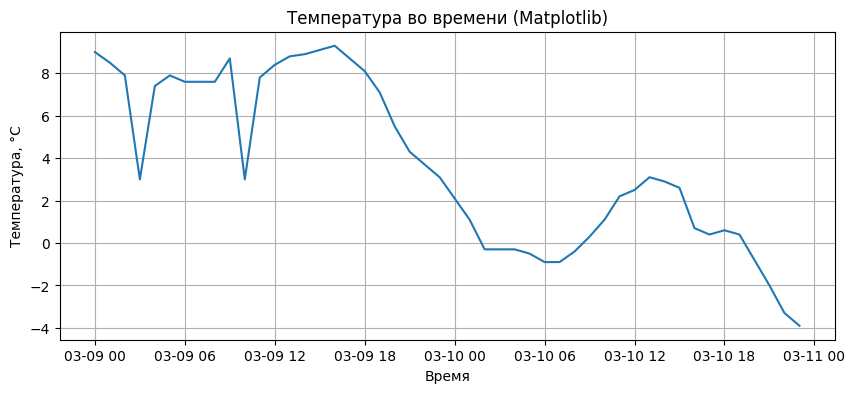

In [26]:
plt.figure(figsize=(10, 4))
plt.plot(df_clean['time'], df_clean['temperature_2m'])
plt.title('Температура во времени (Matplotlib)')
plt.xlabel('Время')
plt.ylabel('Температура, °C')
plt.grid(True)
plt.show()

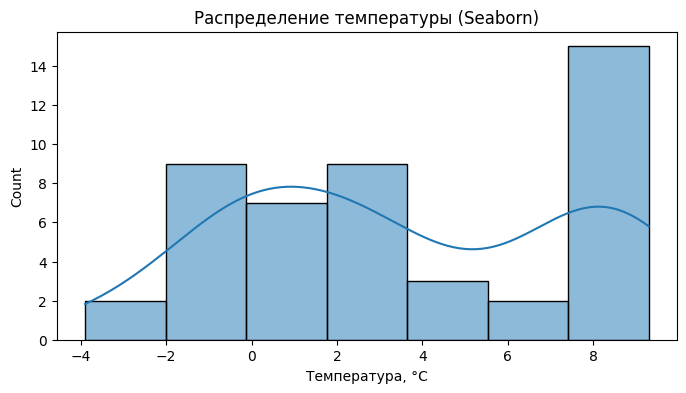

In [28]:
plt.figure(figsize=(8, 4))
sns.histplot(df_clean['temperature_2m'], kde=True)
plt.title('Распределение температуры (Seaborn)')
plt.xlabel('Температура, °C')
plt.show()

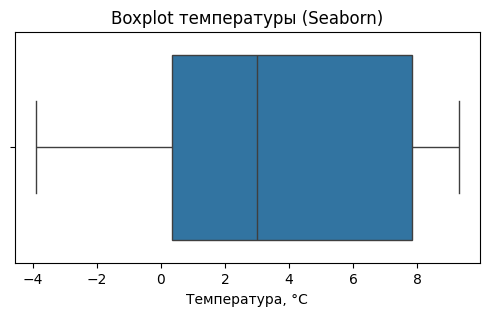

In [29]:
plt.figure(figsize=(6, 3))
sns.boxplot(x=df_clean['temperature_2m'])
plt.title('Boxplot температуры (Seaborn)')
plt.xlabel('Температура, °C')
plt.show()

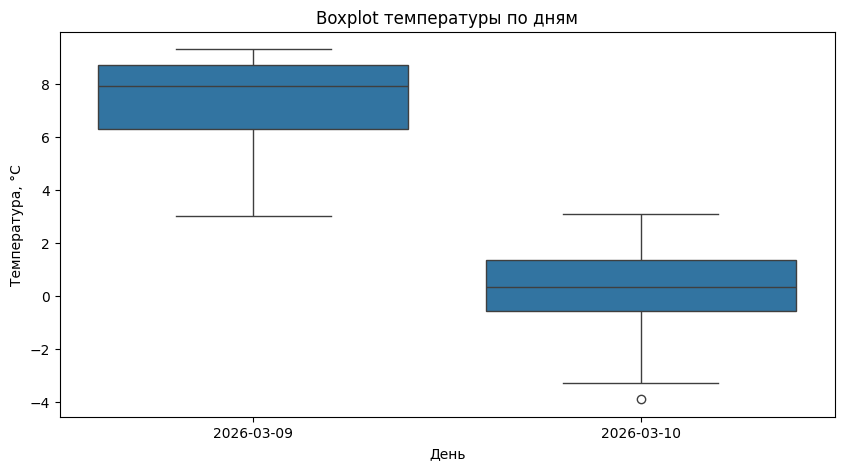

In [30]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_clean['day'], y=df_clean['temperature_2m'])
plt.title('Boxplot температуры по дням')
plt.xlabel('День')
plt.ylabel('Температура, °C')
plt.show()

## **Экспорт результатов и мини-отчет**

In [31]:
df_clean.to_csv('cleaned_data.csv', index=False)
print('saved: cleaned_data.csv')

saved: cleaned_data.csv


Источником данных был открытый API погоды (Open-Meteo), которые предоставлял полуструктурированные JSON-ответы, преобразованные далее в табличный вид DataFrame.

Были выявлены пропуски в temperature_2m, аномалии в temperature_2m и один дубликат.

Для очистки данных применены фильтры: удаление дублей, обработка пропусков (заполнение медианой), фильтрация аномалий по диапазону, а также Pandas-вычисления.

Ключевой вывод - средняя температура за период составила около -0.29 С.

Использованные библиотеки: requests для получения данных из API, pandas для преобразования JSON в табличную структуру и вычислений, matplotlib для базовой визуализации, seaborn для статистической визуализации и оформления графиков. Также был составлен boxplot по дням (Seaborn).

## **Контрольные вопросы**

**В чём различие между структурированными и полуструктурированными данными на примере данной работы?**

В структурированных данных жесткая табличная структура - фиксированные столбцы, типы, схема.
В полуструктурированных данных гибкая структура - вложенность, переменный набор полей.

**Какова роль Requests в мини‑пайплайне? Какие признаки корректного ответа API вы проверяете?**

Роль Requests в мини-пайплане: получение данных из внешних API (HTTP-запросов).
Провека корректности ответа:
** HTTP статус-код
** Content-Type (формат ответа)
** валидность JSON
** таймауты

**Какие задачи удобнее решать NumPy, а какие — Pandas?**

NumPy удобнее для:
* математических операций на массивах
* многомерных массивов (тензоров)
* низкоуровневых численных вычислений
* работы с однородными данными
Pandas удобнее для
* табличных данных (строки + колонки)
* операций с метками (индексы, имена колонок)
* разнородных типов данных
* обработки пропусков, дубликатов
* чтения/записи файлов
* временных рядов

**Чем Matplotlib отличается от Seaborn по уровню абстракции и типовым сценариям применения?**

Matplotlib - низкоуровневая библиотека.
Обеспечивает полный контроль, но требует много кода.
Сценарии:
* нужен полный контроль над каждый элементов
* кастомизация сложных графиков
* базовые графики (линии, точки, бары)
* комбинирование нескольких типов графиков

Seaborn - высокоуровневая библиотека.
Красивые графики из коробки, минимум кода.
* статистические графики (распределения, корреляции)
* красота из коробки (темы, палитры)
* исследовательский анализ (EDA)
* работа с DataFrame (автоматические легенды, группировки)

**Почему диагностика качества данных выполняется до агрегирования и визуализации?**

Если агрегировать сразу, то:
* используются строки вместо чисел
* пропуски искажают статистику
* дубликаты удваивают результаты
Последствия без диагностики:
* конкатенция вместо суммы
* искаженное среднее, графики
* NaN распространяется на агрегаты
* завышенные суммы, counts
* неправильная группировка по времени
